# RED NEURONAL RECURRENTE PARA PREDECIR EL PRECIO DE LA BOLSA DE VALORES

# 1 - IMPORTAMOS LIBRERIAS

In [1]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler

# 2 - CARGAMOS DATASET PARA PRECIOS DE COCA COLA COMPANY(KO)

In [3]:
# Descargar datos históricos de KO (Coca-Cola) desde Yahoo Finance
symbol = "KO"
data = yf.download(symbol, start="2025-01-01", end="2025-11-30")

/tmp/ipython-input-1676360616.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(symbol, start="2025-01-01", end="2025-11-30")
[*********************100%***********************]  1 of 1 completed


In [4]:
data

Price,Close,High,Low,Open,Volume
Ticker,KO,KO,KO,KO,KO
Date,,,,,
2025-01-02,60.067802,60.951724,59.854106,60.563185,12991000
2025-01-03,59.980381,60.300926,59.854105,60.126084,10403200
2025-01-06,59.067322,59.805540,58.921619,59.737547,17924200
2025-01-07,59.096458,59.951241,58.882762,59.358721,17799600
2025-01-08,59.941528,59.999810,59.183883,59.242164,14412400
...,...,...,...,...,...
2025-11-21,72.441185,72.679516,70.991369,71.180046,26492500
2025-11-24,72.083694,72.649726,71.070812,72.649726,39818600


In [5]:
data.columns

MultiIndex([( 'Close', 'KO'),
            (  'High', 'KO'),
            (   'Low', 'KO'),
            (  'Open', 'KO'),
            ('Volume', 'KO')],
           names=['Price', 'Ticker'])

## 3 - RENOMBRAMOS LAS COLUMNAS

In [6]:
# Renombrar las columnas eliminando el MultiIndex y aplicando snake_case
data.columns = [f"{col[0].lower()}_{col[1].lower()}" for col in data.columns]

# Mostrar las nuevas columnas
print(data.head())

             close_ko    high_ko     low_ko    open_ko  volume_ko
Date                                                             
2025-01-02  60.067802  60.951724  59.854106  60.563185   12991000
2025-01-03  59.980381  60.300926  59.854105  60.126084   10403200
2025-01-06  59.067322  59.805540  58.921619  59.737547   17924200
2025-01-07  59.096458  59.951241  58.882762  59.358721   17799600
2025-01-08  59.941528  59.999810  59.183883  59.242164   14412400


## 4 - MODIFICAMOS EL DATASET PARA TRABAJAR SOLO CON EL CLOSE_KO

In [7]:
df = data[['close_ko']]
df = df.rename(columns={'close_ko': 'close'})

In [8]:
df

,close
Date,
2025-01-02,60.067802
2025-01-03,59.980381
2025-01-06,59.067322
2025-01-07,59.096458
2025-01-08,59.941528
...,...
2025-11-21,72.441185
2025-11-24,72.083694
2025-11-25,72.103561


## ESCALAMOS LOS DATOS

In [9]:
# Normalización de datos
scaler = MinMaxScaler(feature_range=(0, 1))
df_scaled = scaler.fit_transform(df)
df_scaled

array([[0.07387613],
       [0.06742087],
       [0.        ],
       [0.00215147],
       [0.06455197],
       [0.01864832],
       [0.06024875],
       [0.08822095],
       [0.06885547],
       [0.1032832 ],
       [0.13627634],
       [0.11547627],
       [0.06957262],
       [0.05164118],
       [0.07961394],
       [0.21947663],
       [0.11117277],
       [0.14488363],
       [0.23238742],
       [0.19150415],
       [0.18217999],
       [0.13340743],
       [0.16568342],
       [0.18289742],
       [0.21732516],
       [0.26824974],
       [0.48700893],
       [0.56662344],
       [0.62328499],
       [0.57809963],
       [0.59101014],
       [0.66416911],
       [0.66201764],
       [0.7559764 ],
       [0.70146575],
       [0.76601715],
       [0.71652829],
       [0.72154895],
       [0.74593508],
       [0.82554902],
       [0.67277555],
       [0.66488626],
       [0.69214102],
       [0.76171365],
       [0.76314796],
       [0.73374117],
       [0.65484438],
       [0.631

## 5 - CREAMOS SERIES TEMPORALES(SECUENCIAS)

In [10]:
def create_sequences(data, seq_length):
    sequences, labels = [], []
    for i in range(len(data) - seq_length):
        sequences.append(data[i:i+seq_length])
        labels.append(data[i+seq_length])
    return np.array(sequences), np.array(labels)

In [12]:
# Definir la longitud de la secuencia (días pasados usados para predecir)
SEQ_LENGTH = 30  # 30 días de datos para predecir el siguiente
X, y = create_sequences(df_scaled, SEQ_LENGTH)


## 6 -  DIVIDIMOS DATASET EN ENTRENAMIENTO Y PRUEBA

In [13]:
from sklearn.model_selection import train_test_split

# Dividir en conjuntos de entrenamiento y prueba (80% entrenamiento, 20% prueba)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## 7 - CREAMOS RED NEURONAL RECURRENTE

In [14]:
model = tf.keras.Sequential([
    tf.keras.layers.LSTM(50, return_sequences=True, input_shape=(SEQ_LENGTH, 1)),
    tf.keras.layers.LSTM(50, return_sequences=False),
    tf.keras.layers.Dense(25, activation="relu"),
    tf.keras.layers.Dense(1)
])

# Compilar el modelo
model.compile(optimizer='adam', loss='mean_squared_error')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [15]:
history = model.fit(X_train, y_train, epochs=100, batch_size=128, validation_data=(X_test, y_test))

Epoch 1/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 7s 725ms/step - loss: 0.5431 - val_loss: 0.3670
Epoch 2/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - loss: 0.3891 - val_loss: 0.2514
Epoch 3/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - loss: 0.2677 - val_loss: 0.1465
Epoch 4/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - loss: 0.1572 - val_loss: 0.0524
Epoch 5/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - loss: 0.0603 - val_loss: 0.0100
Epoch 6/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - loss: 0.0148 - val_loss: 0.0534
Epoch 7/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - loss: 0.0513 - val_loss: 0.0599
Epoch 8/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - loss: 0.0530 - val_loss: 0.0259
Epoch 9/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - loss: 0.0238 - val_loss: 0.0093
Epoch 10/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - loss: 0.0118 - val_loss: 0.0117
Epoch 11/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - loss: 0.0169 - val_loss: 0.0167
Epoch 12/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - loss: 0.0228 - val_

## 8 - CREAMOS GRAFICO DE PREDICCIONES

2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 886ms/step


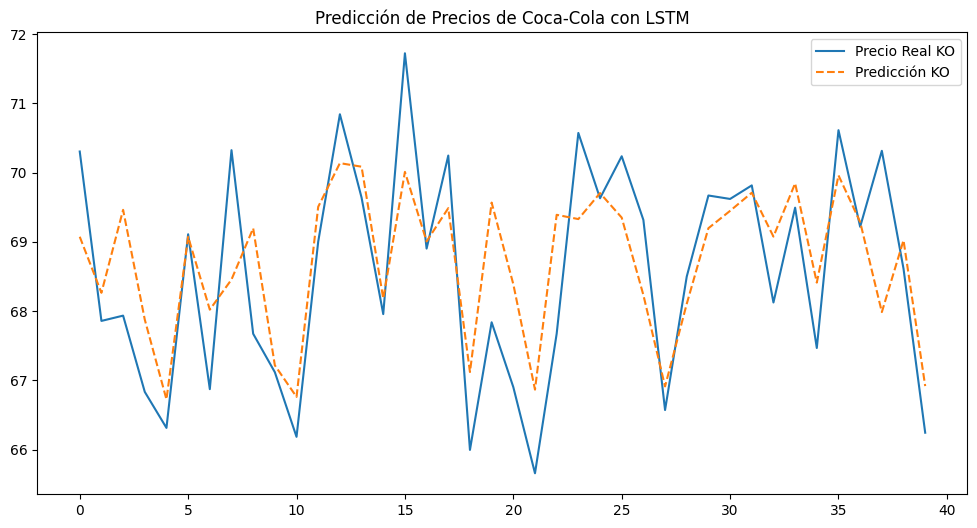

In [16]:
# Predicciones
predictions = model.predict(X_test)
predictions = scaler.inverse_transform(predictions)

# Invertir la escala de los valores reales
real_prices = scaler.inverse_transform(y_test.reshape(-1, 1))

# Visualizar los resultados
plt.figure(figsize=(12,6))
plt.plot(real_prices, label="Precio Real KO")
plt.plot(predictions, label="Predicción KO", linestyle="dashed")
plt.legend()
plt.title("Predicción de Precios de Coca-Cola con LSTM")
plt.show()

## 9 - REALIZAMOS PREDICCIÓN PARA LOS SIGUIENTES 30 DIAS

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━

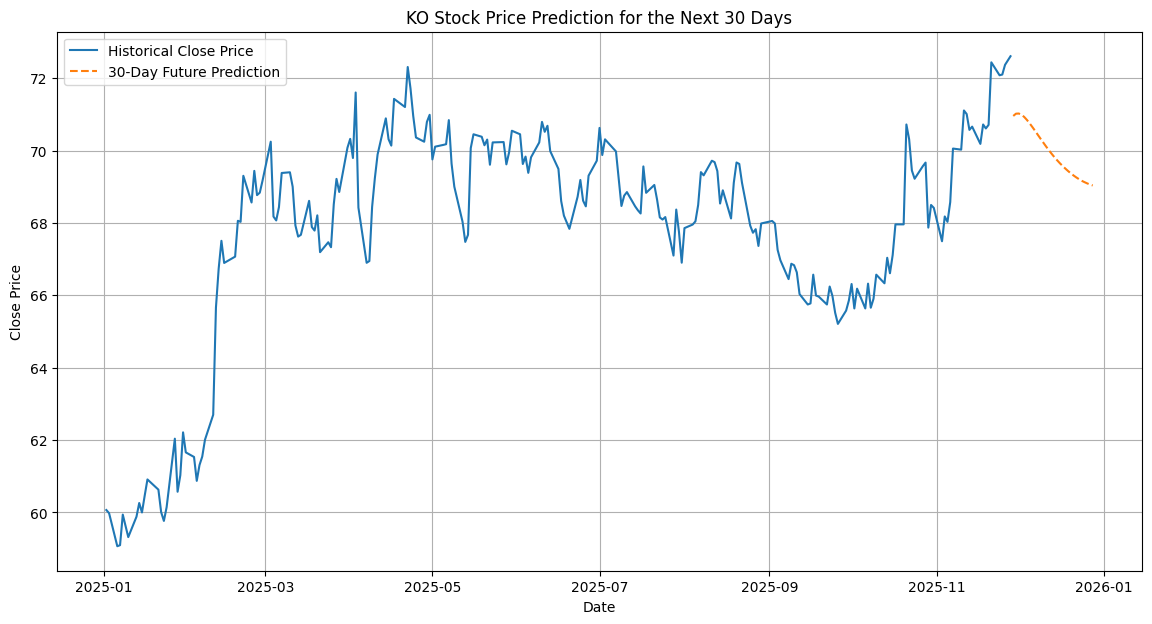

In [18]:
# Prepare initial sequence for future predictions
last_sequence = df_scaled[-SEQ_LENGTH:]
future_predictions = []

# Predict future prices
current_sequence = last_sequence.reshape(1, SEQ_LENGTH, 1)

for _ in range(30): # Predict for the next 30 days
    next_day_prediction = model.predict(current_sequence)[0]
    future_predictions.append(next_day_prediction)
    # Update the sequence: remove the first element and add the new prediction
    current_sequence = np.append(current_sequence[:, 1:, :], [[next_day_prediction]], axis=1)

# Inverse transform predictions
future_predictions = scaler.inverse_transform(np.array(future_predictions).reshape(-1, 1))

# Generate future dates
last_date = df.index[-1]
future_dates = pd.date_range(start=last_date, periods=31, freq='D')[1:] # Start from the day after the last available data

# Create a DataFrame for historical data
historical_data = df.copy()

# Create a DataFrame for future predictions
future_df = pd.DataFrame(future_predictions, index=future_dates, columns=['Predicted Close'])

# Visualize predictions
plt.figure(figsize=(14, 7))
plt.plot(historical_data.index, historical_data['close'], label='Historical Close Price')
plt.plot(future_df.index, future_df['Predicted Close'], label='30-Day Future Prediction', linestyle='--')
plt.title(f'KO Stock Price Prediction for the Next 30 Days')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.grid(True)
plt.show()
